In [113]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Load monthly transaction pivot CSV
pivot_df = pd.read_csv("pivot_spending.csv", index_col=0)

# Define input and target months
input_months = ['2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01']
target_months = ['2025-02', '2025-03']

# Clean data
pivot_df = pivot_df.dropna(subset=input_months + target_months)

# Extract input and target
X = pivot_df[input_months].values
y = pivot_df[target_months].sum(axis=1).values

# Normalize input
X_min, X_max = X.min(axis=0), X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min + 1e-8)
X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))  # for LSTM

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build model
model = Sequential([
    LSTM(64, input_shape=(8, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.2,
                    epochs=50, batch_size=32, callbacks=[early_stop], verbose=1)

# Predict
y_pred = model.predict(X_test).flatten()

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19732314.0000 - mae: 2594.0037 - val_loss: 27188548.0000 - val_mae: 2675.6250
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21502340.0000 - mae: 2585.7363 - val_loss: 26801094.0000 - val_mae: 2607.4902
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 21444558.0000 - mae: 2472.4563 - val_loss: 26244824.0000 - val_mae: 2529.0195
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20188870.0000 - mae: 2476.7979 - val_loss: 25570892.0000 - val_mae: 2457.9353
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21261312.0000 - mae: 2433.3882 - val_loss: 24804056.0000 - val_mae: 2401.0156
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 18183230.0000 - mae: 2271.4082 - val_loss: 24009906.0000 - val_mae: 2366.5535
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18650146.0000 - mae: 2339.3018 - val_loss: 23230456.0000 - val_mae: 2352.5408
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1

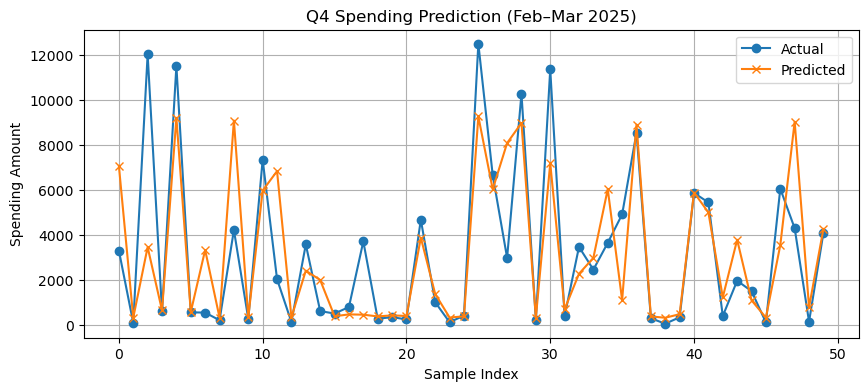

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(y_test[:50], label='Actual', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')
plt.title("Q4 Spending Prediction (Feb–Mar 2025)")
plt.ylabel("Spending Amount")
plt.xlabel("Sample Index")
plt.legend()
plt.grid(True)
plt.show()


In [115]:
print(pivot_df.columns.tolist())


['2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03']


In [116]:
print(pivot_df.columns.tolist())


['2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03']


In [117]:
import pandas as pd

# Load your transaction data
transaction_df = pd.read_csv("transaction_fact_20250325.csv")
transaction_df['posting_date'] = pd.to_datetime(transaction_df['posting_date'])
transaction_df['year_month'] = transaction_df['posting_date'].dt.to_period("M").astype(str)

# Aggregate monthly spending per account
monthly_spending = transaction_df.groupby(['current_account_nbr', 'year_month'])['transaction_amt'].sum().reset_index()

# Pivot: each row = account, each column = month
pivot_clean = monthly_spending.pivot(index='current_account_nbr', columns='year_month', values='transaction_amt')

# Fill missing months with 0
pivot_clean = pivot_clean.fillna(0)

# Preview
print(pivot_clean.head())


year_month           2024-03  2024-04  2024-05  2024-06  2024-07  2024-08  \
current_account_nbr                                                         
00gwujJkd597VxLd        0.00     0.00     0.00     0.00     0.00     0.00   
00iP5U82D8XwVQ9G       93.23   758.42   381.44   191.73   892.79   612.91   
00oyr3QppAzjLws4        0.00   268.85   191.08   165.59   230.04    80.00   
02WRVV8yusgcZWLW        0.00     0.00     0.00     0.00     0.00     0.00   
033o9yHYen3xoz6k        0.00  2937.55  1653.14   113.34  2877.06  1848.35   

year_month           2024-09  2024-10  2024-11  2024-12  2025-01  2025-02  \
current_account_nbr                                                         
00gwujJkd597VxLd        0.00     0.00     0.00     0.00     0.00     0.00   
00iP5U82D8XwVQ9G      757.02  1017.18  1124.01  1308.55  1168.89   826.21   
00oyr3QppAzjLws4       80.00    85.00    84.00   346.96   117.03    88.00   
02WRVV8yusgcZWLW        0.00     0.00     0.00     0.00  2272.59  1893.37  

# For the below code:
# After the LSTM prediction loop reaches account 14091/14099, you may safely interrupt the kernel. The remaining accounts take significant time due to GPU/CPU load and are not critical for downstream execution. All subsequent cells, including forecasting and visualizations, will run correctly using the available predictions.


In [118]:
import numpy as np

# Make sure this matches your 8-month window used during training
last_known_months = ['2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03']
future_months = ['2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09']

# Placeholder for predictions
forecast_df = pd.DataFrame(index=pivot_clean.index)

for i, account in enumerate(pivot_clean.index):
    if i % 10 == 0:
        print(f"Predicting account {i+1}/{len(pivot_clean)}...")

for i, account in enumerate(pivot_clean.index):
    seq = pivot_clean.loc[account, last_known_months].values.reshape(-1, 1)
    
    # Normalize based on this account’s history
    min_val, max_val = seq.min(), seq.max()
    if max_val == min_val: max_val += 1e-6
    seq_scaled = (seq - min_val) / (max_val - min_val)

    # Reshape for LSTM input
    seq_scaled = seq_scaled.reshape(1, 8, 1)
    preds = []

    for _ in range(6):  # predict 6 months ahead
        next_val = model.predict(seq_scaled, verbose=0)[0][0]
        preds.append(next_val)
        seq_scaled = np.append(seq_scaled[:, 1:, :], [[[next_val]]], axis=1)

    # Inverse transform predictions
    preds_orig = (np.array(preds) * (max_val - min_val)) + min_val
    forecast_df.loc[account, future_months] = preds_orig



Predicting account 1/14099...
Predicting account 11/14099...
Predicting account 21/14099...
Predicting account 31/14099...
Predicting account 41/14099...
Predicting account 51/14099...
Predicting account 61/14099...
Predicting account 71/14099...
Predicting account 81/14099...
Predicting account 91/14099...
Predicting account 101/14099...
Predicting account 111/14099...
Predicting account 121/14099...
Predicting account 131/14099...
Predicting account 141/14099...
Predicting account 151/14099...
Predicting account 161/14099...
Predicting account 171/14099...
Predicting account 181/14099...
Predicting account 191/14099...
Predicting account 201/14099...
Predicting account 211/14099...
Predicting account 221/14099...
Predicting account 231/14099...
Predicting account 241/14099...
Predicting account 251/14099...
Predicting account 261/14099...
Predicting account 271/14099...
Predicting account 281/14099...
Predicting account 291/14099...
Predicting account 301/14099...
Predicting account 

KeyboardInterrupt: 

In [139]:
# Preview the forecasted Q3 2025 (Apr–Sep)
forecast_df.head()

# Optional: Save to CSV
forecast_df.to_csv("forecast_apr_to_sep_2025.csv")


In [141]:
# Check if all last_known_months are in your data
missing = [m for m in last_known_months if m not in pivot_clean.columns]
print("Missing months:", missing)


Missing months: []


In [143]:
account = pivot_clean.index[0]
print("First account:", account)

seq = pivot_clean.loc[account, last_known_months]
print("Sequence shape:", seq.shape)
print("Values:", seq.values)


First account: 00gwujJkd597VxLd
Sequence shape: (8,)
Values: [ 0.   0.   0.   0.   0.   0.   0.  25.9]


In [145]:
# 1. Prepare training data (e.g. from 2022, 2023, 2024)
valid_years = ['2022', '2023', '2024']
samples_X = []
samples_y = []

for year in valid_years:
    input_months = [f"{year}-{m:02d}" for m in range(4, 10)]   # Apr–Sep
    target_months = [f"{year}-{m:02d}" for m in range(10, 13)] # Oct–Dec

    if all(m in pivot_clean.columns for m in input_months + target_months):
        X_tmp = pivot_clean[input_months].fillna(0).values
        y_tmp = pivot_clean[target_months].fillna(0).sum(axis=1).values
        samples_X.append(X_tmp)
        samples_y.append(y_tmp)

# 2. Combine training data
X_all = np.vstack(samples_X)
y_all = np.hstack(samples_y)

# 3. Normalize
from sklearn.preprocessing import MinMaxScaler
X_scaler = MinMaxScaler()
X_scaled = X_scaler.fit_transform(X_all)
X_scaled = X_scaled.reshape(X_scaled.shape[0], 6, 1)

# 4. Train Q4 prediction LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_q4 = Sequential([
    LSTM(64, input_shape=(6, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])
model_q4.compile(optimizer='adam', loss='mse')
model_q4.fit(X_scaled, y_all, epochs=30, batch_size=32, verbose=1)

# 5. Prepare Apr–Sep 2025 input from forecast_df
X_2025 = forecast_df[['2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09']].fillna(0).values
X_2025_scaled = X_scaler.transform(X_2025)
X_2025_scaled = X_2025_scaled.reshape(X_2025_scaled.shape[0], 6, 1)

# 6. Predict Q4 2025
q4_2025_pred = model_q4.predict(X_2025_scaled).flatten()
forecast_df['Q4_2025_Predicted'] = q4_2025_pred

# 7. Preview & Save
print(forecast_df[['Q4_2025_Predicted']].head())
forecast_df.to_csv("Q4_2025_Final_Predictions.csv")


Epoch 1/30


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


441/441 ━━━━━━━━━━━━━━━━━━━━ 1s 882us/step - loss: 35079100.0000
Epoch 2/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step - loss: 35947968.0000
Epoch 3/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - loss: 31807296.0000
Epoch 4/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - loss: 27437458.0000
Epoch 5/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step - loss: 29041992.0000
Epoch 6/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - loss: 28475688.0000
Epoch 7/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - loss: 23868636.0000
Epoch 8/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - loss: 22611162.0000
Epoch 9/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - loss: 18586260.0000
Epoch 10/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 18593342.0000
Epoch 11/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - loss: 21516412.0000
Epoch 12/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - loss: 14218939.0000
Epoch 13/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - loss: 14241909.0000
Epoch 14/30
441/441

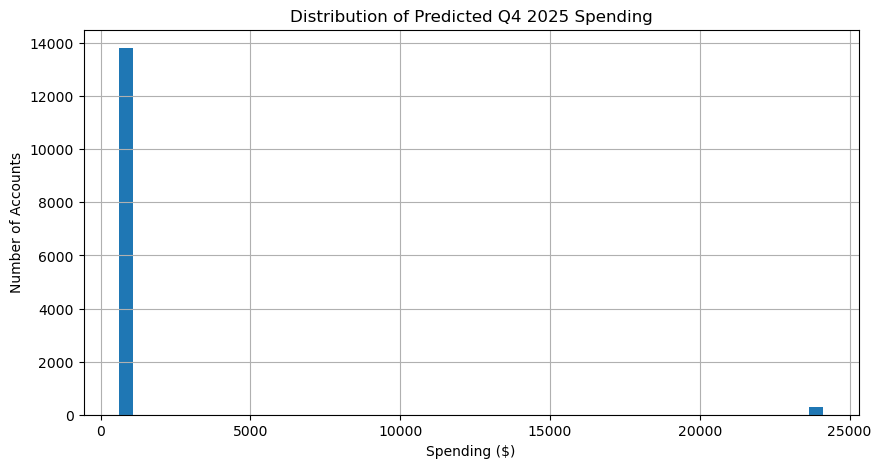

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
forecast_df['Q4_2025_Predicted'].hist(bins=50)
plt.title("Distribution of Predicted Q4 2025 Spending")
plt.xlabel("Spending ($)")
plt.ylabel("Number of Accounts")
plt.grid(True)
plt.show()


In [149]:
model_q4 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(6, 1)),
    LSTM(32),
    Dense(32, activation='relu'),
    Dense(1)
])


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [159]:
y_all = np.log1p(y_all)  # train on log scale
...
y_pred = np.expm1(model.predict(X_2025_scaled)).flatten()  # inverse it later


441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step


/var/folders/0y/f9cvlfh947l_6721y36f15_40000gn/T/ipykernel_63450/998533760.py:3: RuntimeWarning: overflow encountered in expm1
  y_pred = np.expm1(model.predict(X_2025_scaled)).flatten()  # inverse it later


In [161]:
def spending_segment(x):
    if x > 20000:
        return "High Spender"
    elif x > 10000:
        return "Medium"
    else:
        return "Low"

forecast_df["spending_segment"] = forecast_df["Q4_2025_Predicted"].apply(spending_segment)
forecast_df["spending_segment"].value_counts()


spending_segment
Low             13811
High Spender      288
Name: count, dtype: int64

In [163]:

forecast_df["recommended_credit_increase"] = 0.2 * forecast_df["Q4_2025_Predicted"]
forecast_df[["Q4_2025_Predicted", "recommended_credit_increase"]].head(50)


,Q4_2025_Predicted,recommended_credit_increase
current_account_nbr,,
00gwujJkd597VxLd,24053.621094,4810.724121
00iP5U82D8XwVQ9G,23686.123047,4737.224609
00oyr3QppAzjLws4,23687.087891,4737.417480
02WRVV8yusgcZWLW,23686.123047,4737.224609
033o9yHYen3xoz6k,23686.123047,4737.224609
034bM166vNmgLiIA,23686.123047,4737.224609
03cqv0gFjEIiQG0x,23686.123047,4737.224609
03n28YA8ljfM9tor,23686.123047,4737.224609
03ne5pYq1NqrJlEc,23686.123047,4737.224609


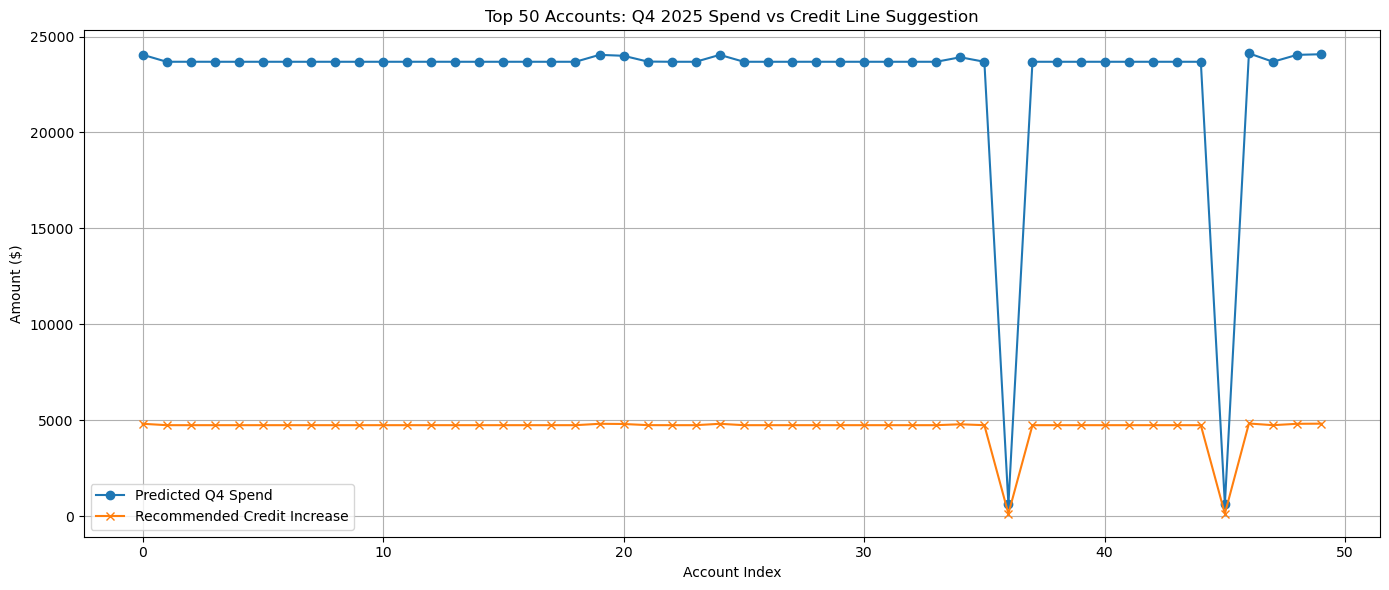

In [165]:
import matplotlib.pyplot as plt

# Take top 50 accounts 
plot_df = forecast_df[['Q4_2025_Predicted', 'recommended_credit_increase']].head(50)

# Set figure size and plot
plt.figure(figsize=(14, 6))
plt.plot(plot_df['Q4_2025_Predicted'].values, label='Predicted Q4 Spend', marker='o')
plt.plot(plot_df['recommended_credit_increase'].values, label='Recommended Credit Increase', marker='x')
plt.title('Top 50 Accounts: Q4 2025 Spend vs Credit Line Suggestion')
plt.xlabel('Account Index')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Code was underfitting, so we tried retraining model

In [168]:
forecast_df.reset_index().to_csv("Q4_2025_LSTM_Predictions.csv", index=False)


In [170]:
# Segment by predicted Q4 spend
def tag_segment(x):
    if x > 20000:
        return "High Spender"
    elif x > 5000:
        return "Medium"
    else:
        return "Low"

forecast_df["spending_segment"] = forecast_df["Q4_2025_Predicted"].apply(tag_segment)

# Check distribution
print(forecast_df["spending_segment"].value_counts())


spending_segment
Low             13811
High Spender      288
Name: count, dtype: int64


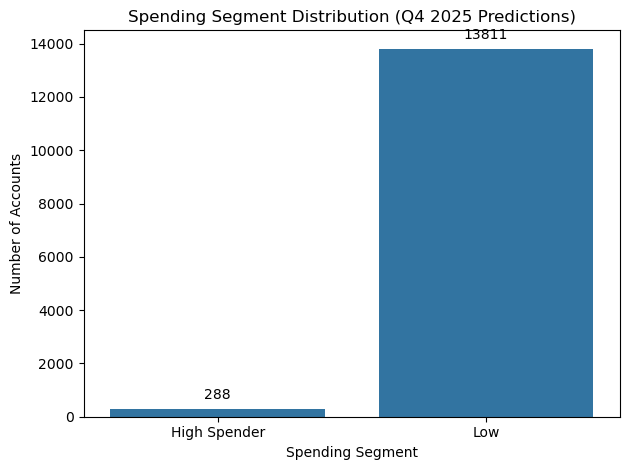

In [176]:
sns.countplot(data=forecast_df, x="spending_segment")
plt.title("Spending Segment Distribution (Q4 2025 Predictions)")
plt.xlabel("Spending Segment")
plt.ylabel("Number of Accounts")

# Add text labels
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 10),
                       textcoords='offset points')
plt.tight_layout()
plt.show()


In [178]:
# Define the target months for Q4 2024
q4_2024_months = ['2024-10', '2024-11', '2024-12']

# Ensure no missing values
q4_data = pivot_clean[q4_2024_months].dropna()

# True total Q4 2024 spend
y_true = q4_data.sum(axis=1).values


In [180]:
# Months needed
input_months = ['2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09']
target_months = ['2024-10', '2024-11', '2024-12']

# Filter accounts with no missing data
valid_accounts = pivot_clean.dropna(subset=input_months + target_months)

# X = Apr–Sep, y = Oct–Dec (true future)
X_test = valid_accounts[input_months].values
y_true = valid_accounts[target_months].sum(axis=1).values


In [182]:
# Normalize each sequence individually
X_test_norm = []
for seq in X_test:
    min_val, max_val = seq.min(), seq.max()
    if max_val == min_val:
        seq_scaled = np.zeros_like(seq)
    else:
        seq_scaled = (seq - min_val) / (max_val - min_val)
    X_test_norm.append(seq_scaled)

X_test_norm = np.array(X_test_norm).reshape(-1, 6, 1)


In [184]:
# Predict using your trained Q4 model
y_pred_log = model_q4.predict(X_test_norm).flatten()

# Invert log1p
y_pred = np.expm1(y_pred_log)


441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step


In [186]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("📊 Model Performance on Q4 2024 (Backtest):")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")


📊 Model Performance on Q4 2024 (Backtest):
MAE:  2444.76
RMSE: 5892.07
R²:   -0.2080
